In [ ]:
!pip install tensorflow

In [ ]:
print("""Cardiovascular Disease Prediction\n

Beginner AI Engineer Project\n

Author:\n
Robbi Sai Ganesh Devi Prasad""")

Cardiovascular Disease Prediction using Machine Learning


Beginner AI Engineer Project


Author:

Robbi Sai Ganesh Devi Prasad


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Cardio Dataset.csv to Cardio Dataset.csv


In [ ]:
df = pd.read_csv("/content/Cardio Dataset.csv", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [ ]:
df.isnull().sum()

df.duplicated().sum()

df.drop_duplicates(inplace=True)


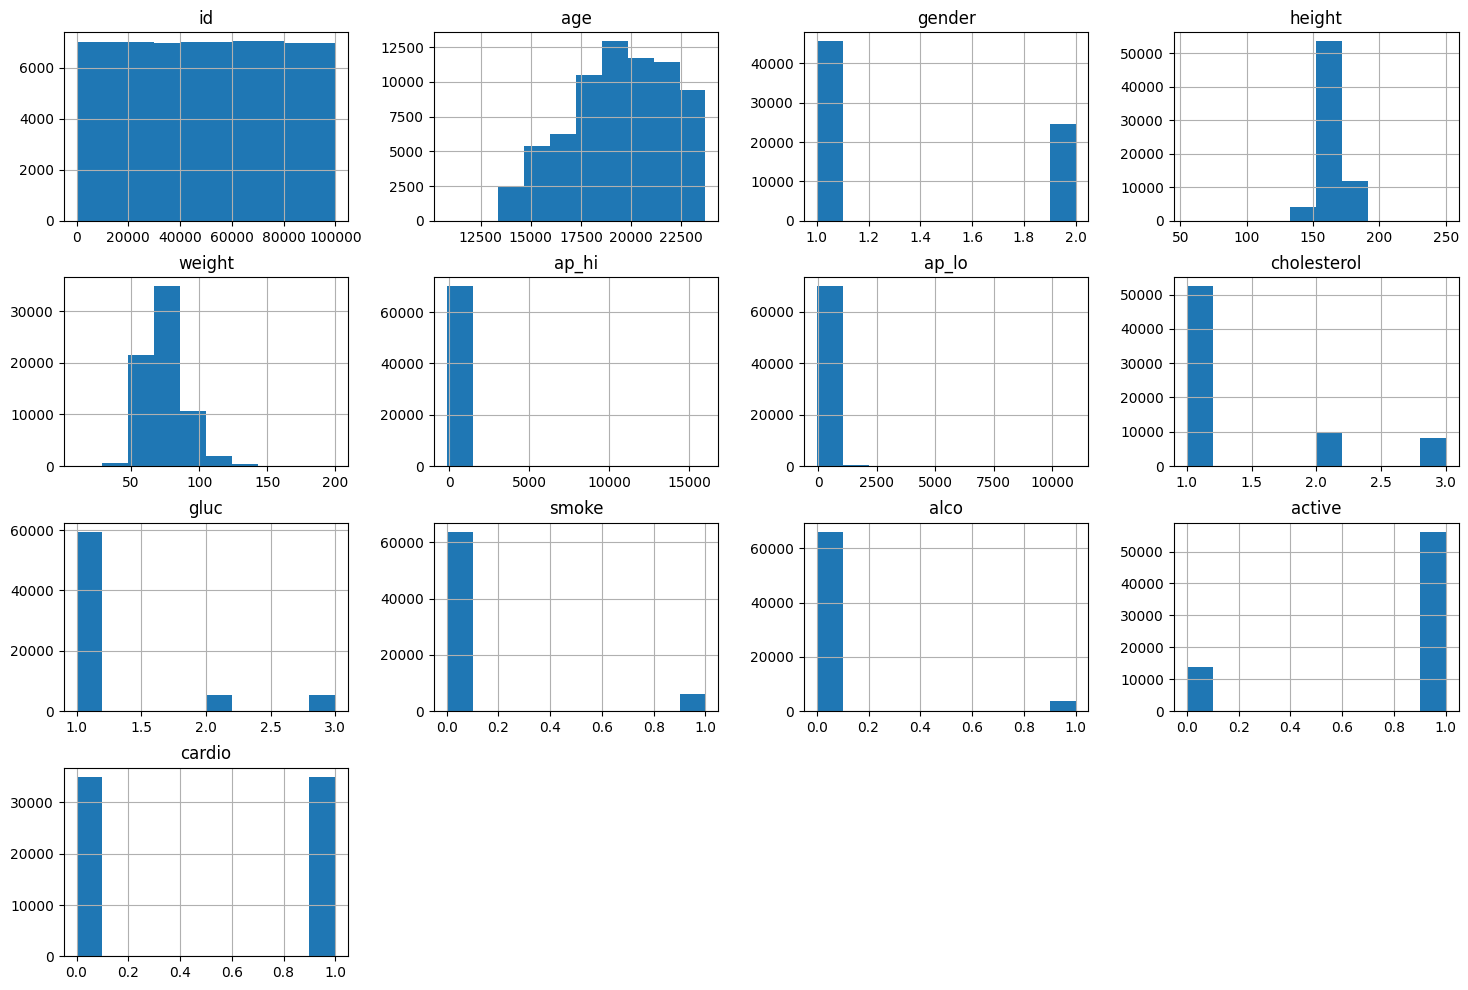

In [ ]:
df.hist(figsize=(18,12))
plt.show()

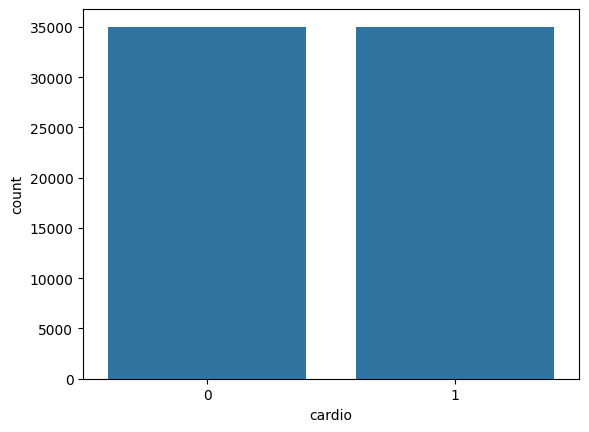

In [ ]:
sns.countplot(x='cardio',data=df)
plt.show()

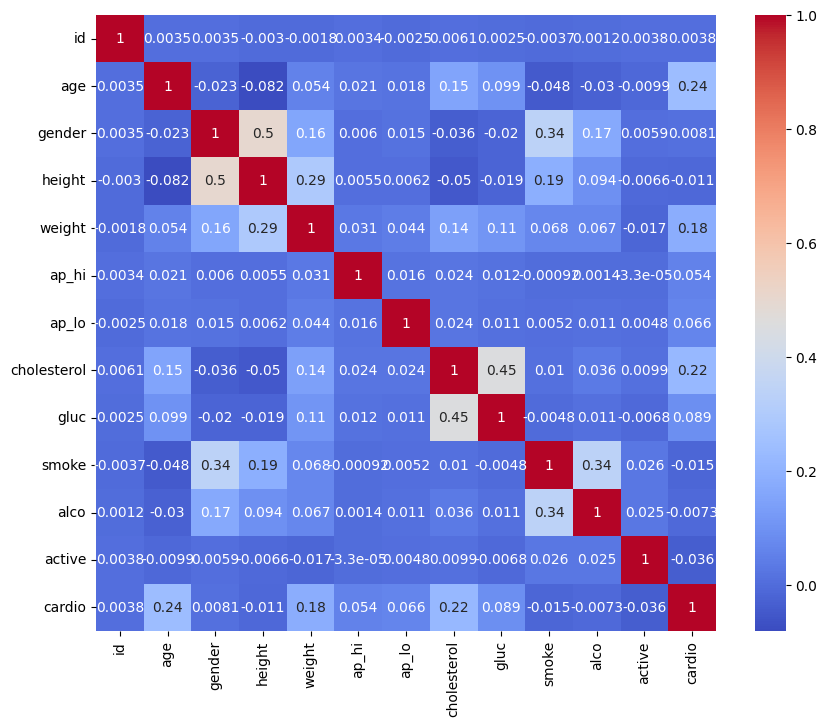

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
X=df.drop("cardio",axis=1)

y=df["cardio"]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [ ]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

print(accuracy_score(y_test,pred_lr))

0.7233571428571428


In [ ]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

print(accuracy_score(y_test,pred_knn))

0.6278571428571429


In [ ]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

print(accuracy_score(y_test,pred_dt))

0.6361428571428571


In [ ]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print(accuracy_score(y_test,pred_rf))

0.7245


In [ ]:
svm=SVC()

svm.fit(X_train,y_train)

pred_svm=svm.predict(X_test)

print(accuracy_score(y_test,pred_svm))

0.7298571428571429


In [ ]:
scores=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_svm)
    ]
})

scores

,Model,Accuracy
0,Logistic Regression,0.723357
1,KNN,0.627857
2,Decision Tree,0.636143
3,Random Forest,0.724500
4,SVM,0.729857


In [ ]:
scores.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
4,SVM,0.729857
3,Random Forest,0.724500
0,Logistic Regression,0.723357
2,Decision Tree,0.636143
1,KNN,0.627857


In [ ]:
scores.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
4,SVM,0.729857
3,Random Forest,0.724500
0,Logistic Regression,0.723357
2,Decision Tree,0.636143
1,KNN,0.627857


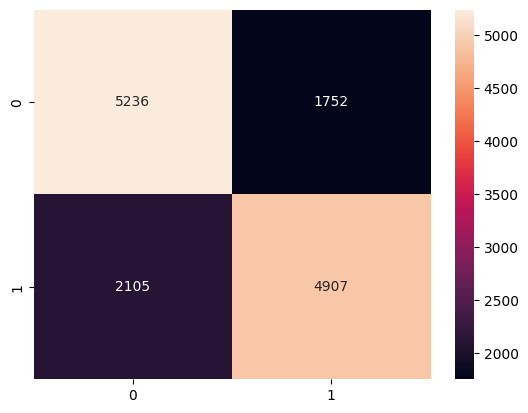

In [ ]:
cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

In [ ]:
print(classification_report(
    y_test,
    pred_rf
))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      6988
           1       0.74      0.70      0.72      7012

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000



In [ ]:
import joblib

joblib.dump(rf,"heart_model.pkl")

['heart_model.pkl']

In [ ]:
model=joblib.load("heart_model.pkl")

In [ ]:
sample=X_test[0].reshape(1,-1)

prediction=model.predict(sample)

print("Prediction: ",prediction)

Prediction:  [1]


In [ ]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Dropout Layer
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model

<Sequential name=sequential, built=True>

In [ ]:
early_stop=EarlyStopping(
    monitor="val_loss",
    mode="min",
    verbose=1,
    patience=25,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6776 - loss: 0.6142 - val_accuracy: 0.7287 - val_loss: 0.5596
Epoch 2/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7213 - loss: 0.5701 - val_accuracy: 0.7315 - val_loss: 0.5559
Epoch 3/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7259 - loss: 0.5599 - val_accuracy: 0.7324 - val_loss: 0.5509
Epoch 4/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7269 - loss: 0.5534 - val_accuracy: 0.7346 - val_loss: 0.5467
Epoch 5/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7290 - loss: 0.5508 - val_accuracy: 0.7333 - val_loss: 0.5458
Epoch 6/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7305 - loss: 0.5484 - val_accuracy: 0.7359 - val_loss: 0.5432
Epoch 7/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7302 - loss: 0.5482 - val_accuracy: 0.7352 - val_loss: 0.5439
Epoch 8/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7308 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7406 - loss: 0.5444
Test Loss : 0.5443715453147888
Test Accuracy : 0.7405714392662048


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


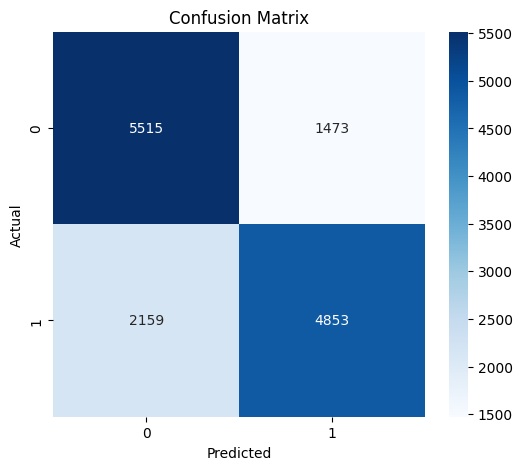

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

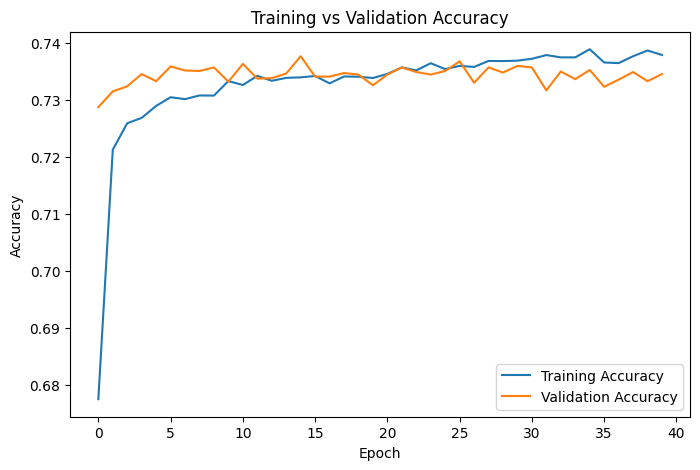

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

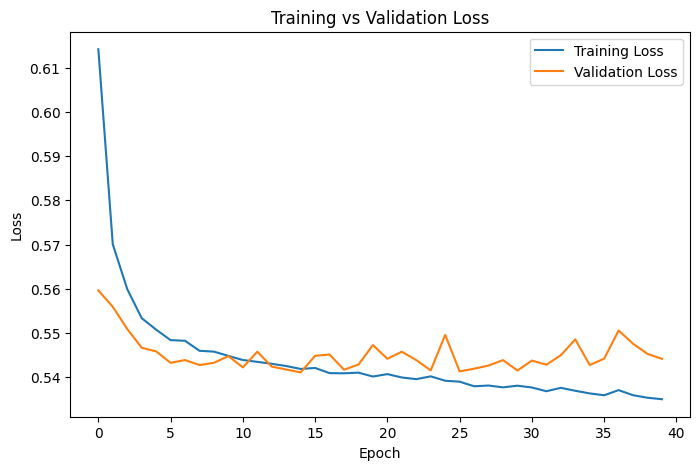

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
model.save("heart_disease_ann.keras")
loaded_model = tf.keras.models.load_model("heart_disease_ann.keras")

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

if prediction[0][0] > 0.5:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Heart Disease Detected


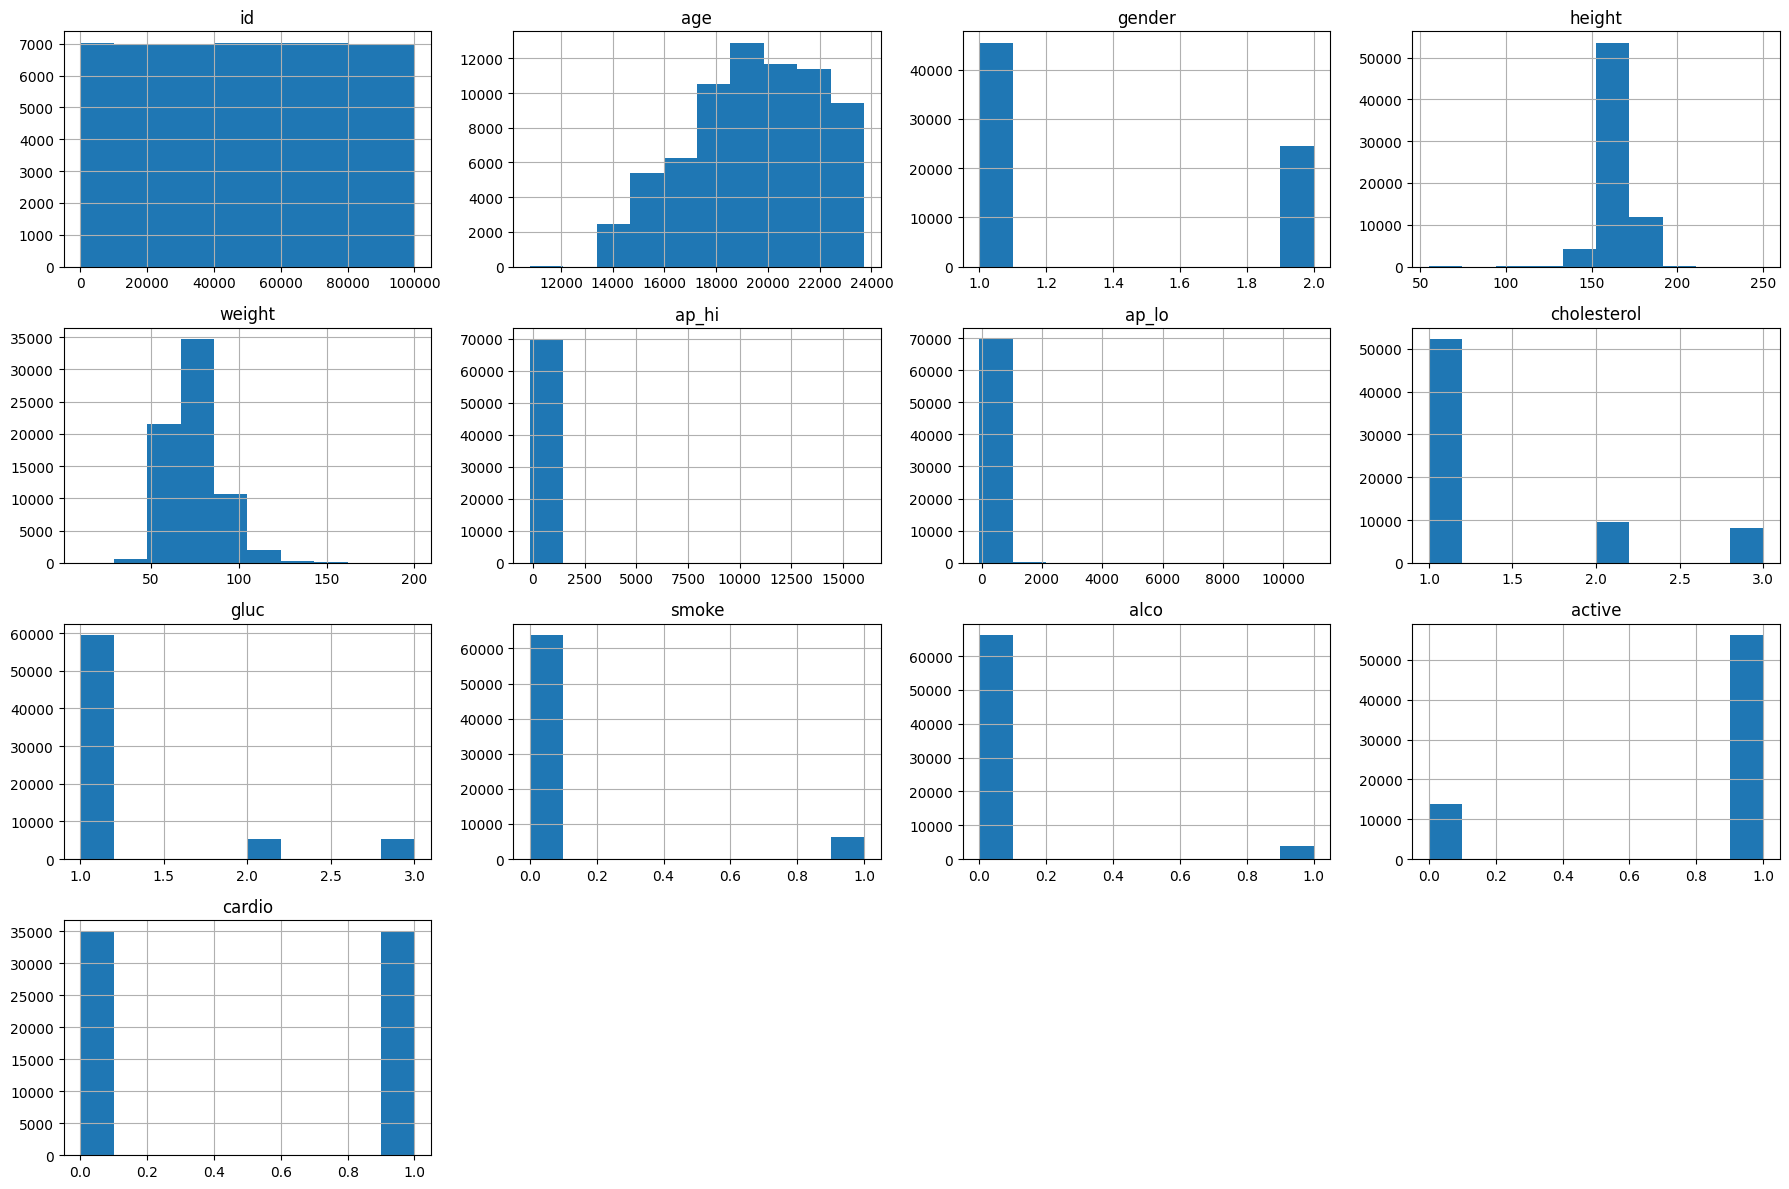

In [ ]:
import os

df.hist(figsize=(18,12))

plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs("output/images", exist_ok=True)
plt.savefig("output/images/histogram.png", dpi=300, bbox_inches="tight")

plt.show()

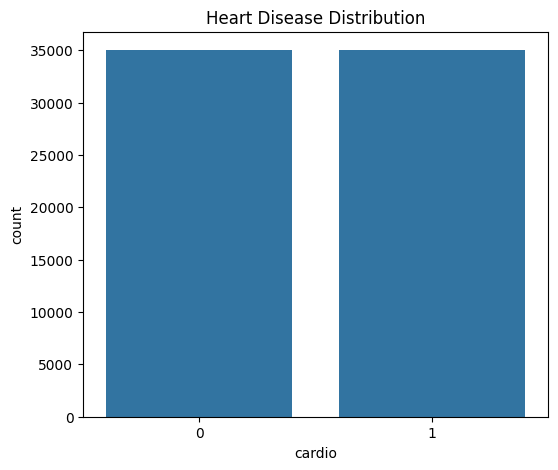

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x="cardio", data=df)

plt.title("Heart Disease Distribution")

plt.savefig("output/images/countplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

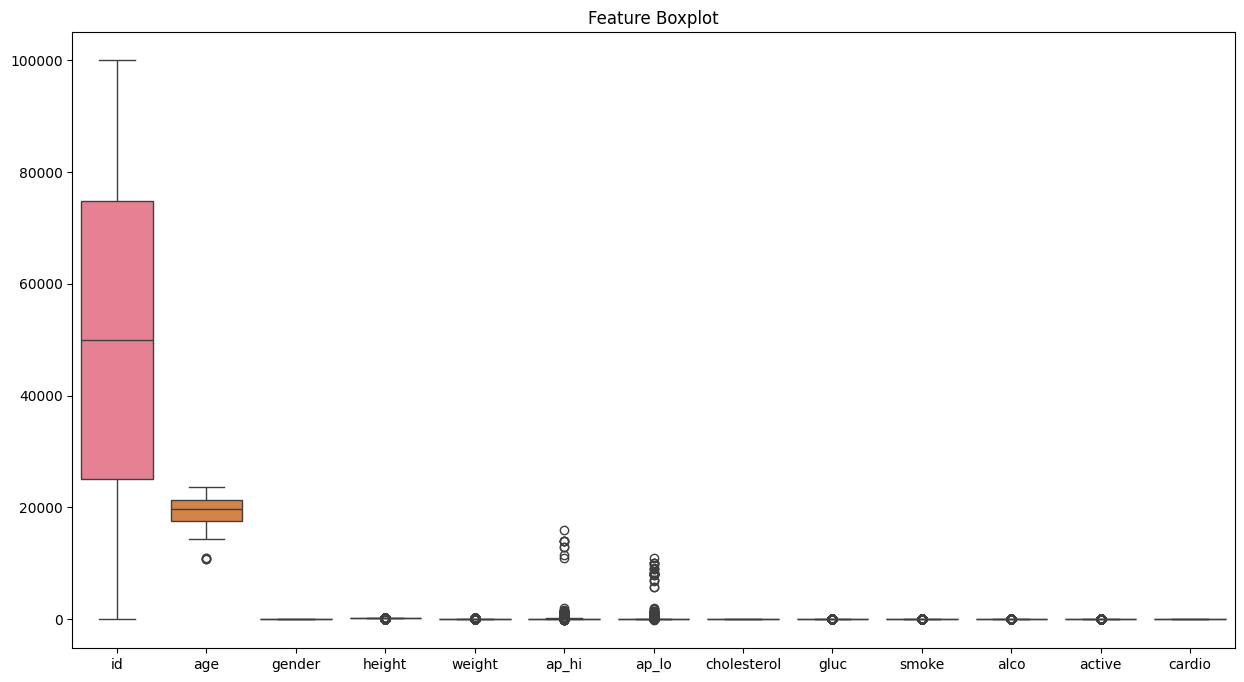

In [ ]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.title("Feature Boxplot")

plt.savefig("output/images/boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

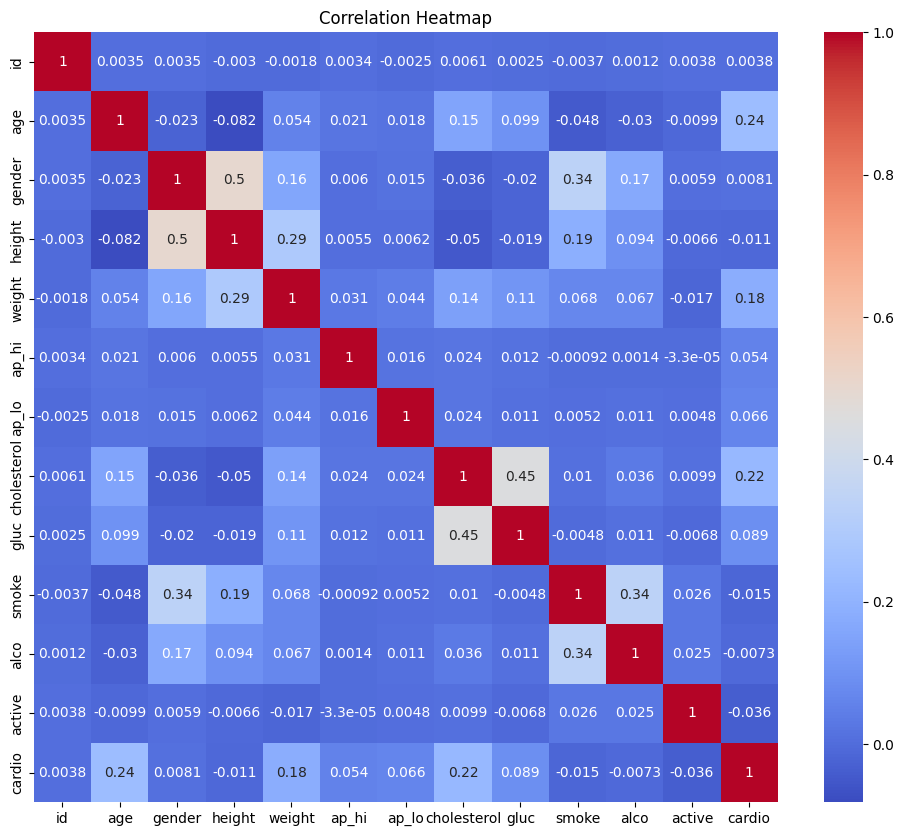

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("output/images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

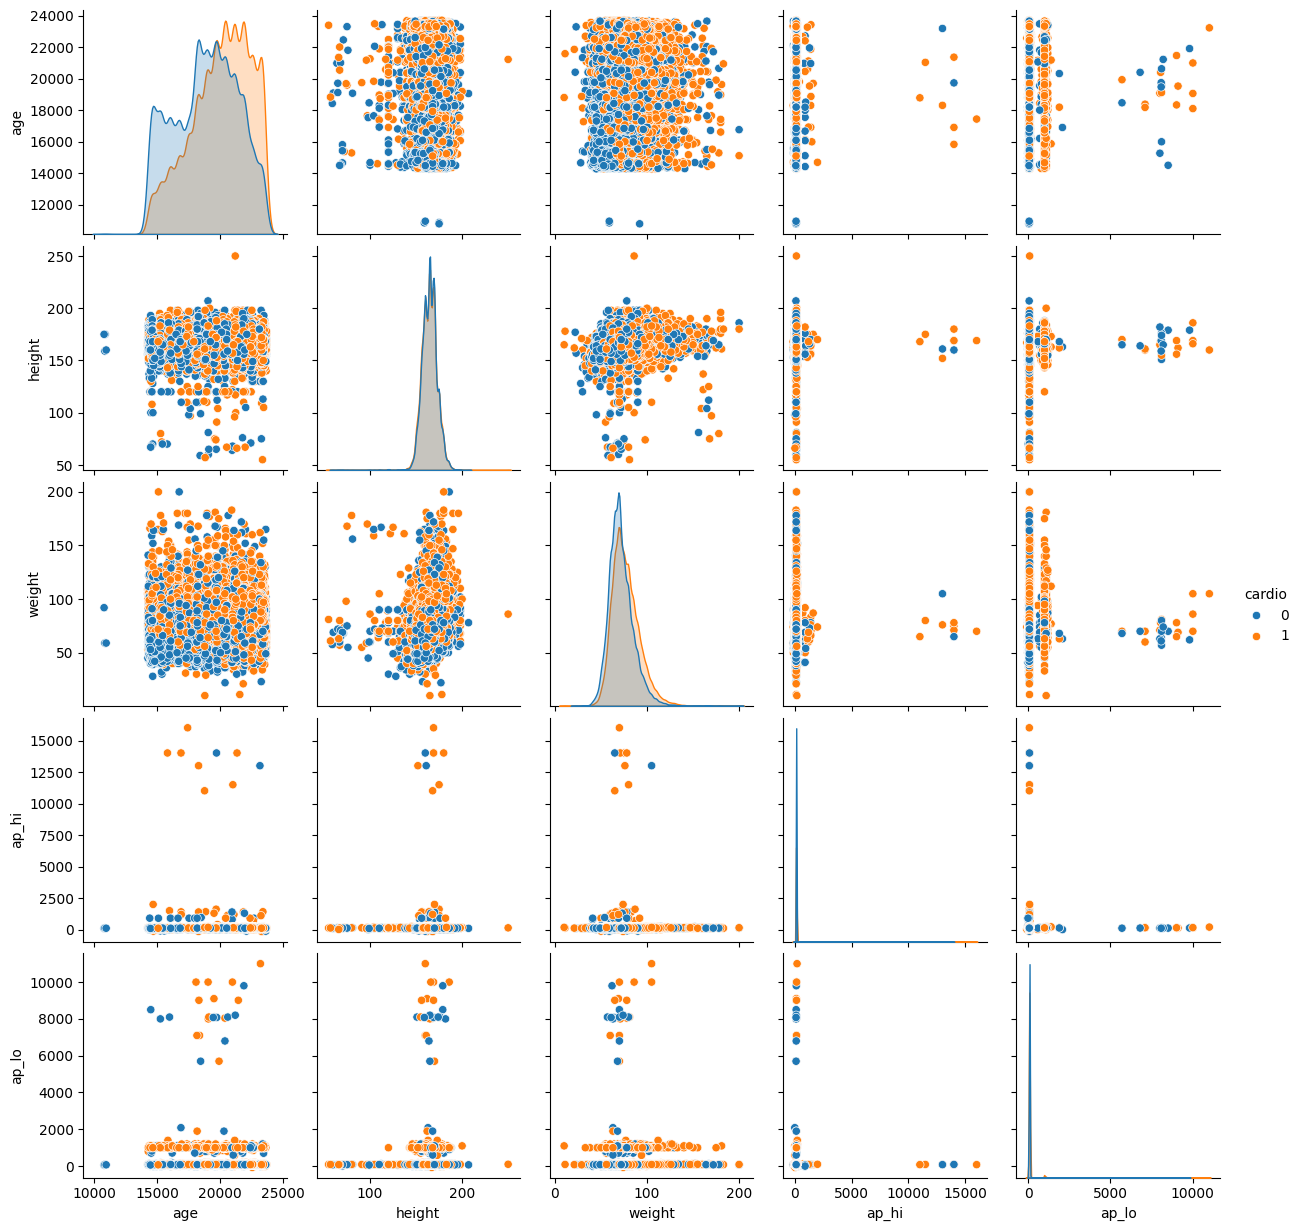

In [ ]:
pair = sns.pairplot(df[['age','height','weight','ap_hi','ap_lo','cardio']],
                    hue='cardio')

pair.savefig("output/images/pairplot.png", dpi=300)

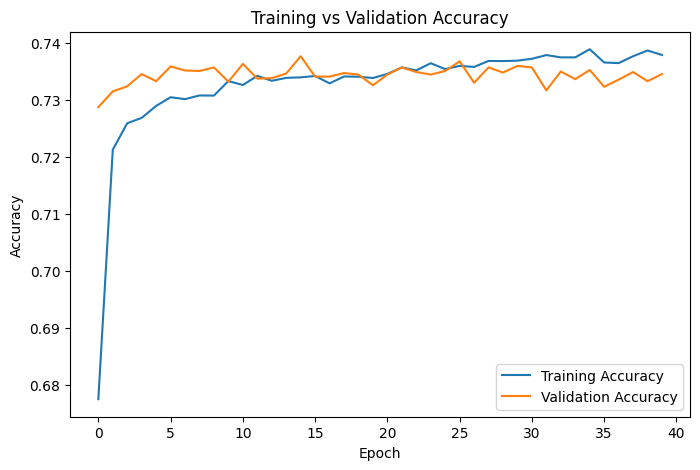

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig("output/images/training_accuracy.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

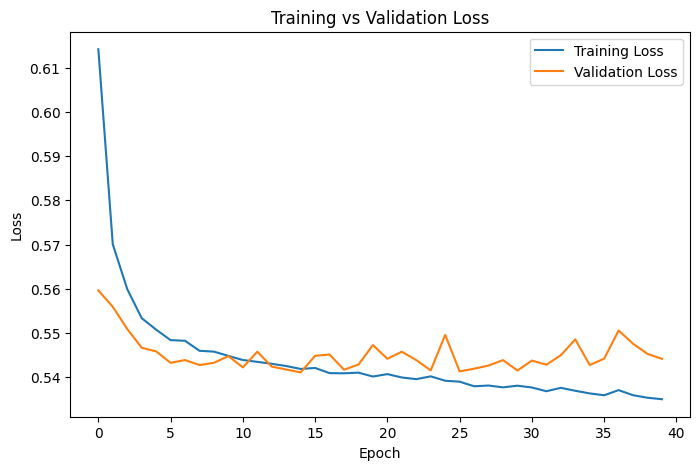

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("output/images/training_loss.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("output/images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

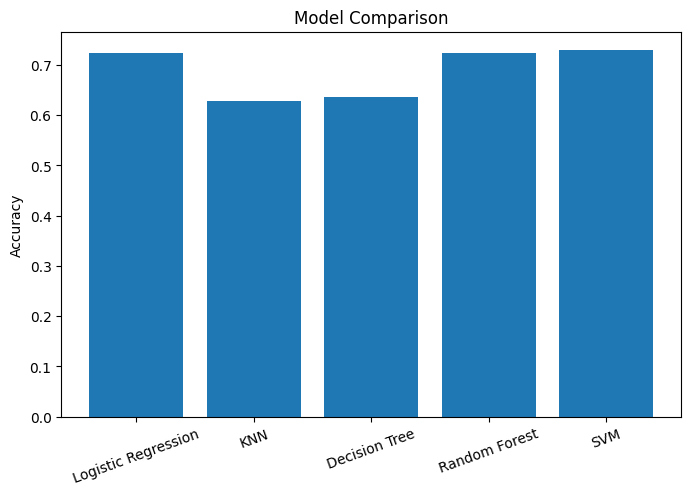

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(scores["Model"], scores["Accuracy"])

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.savefig("output/images/model_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step


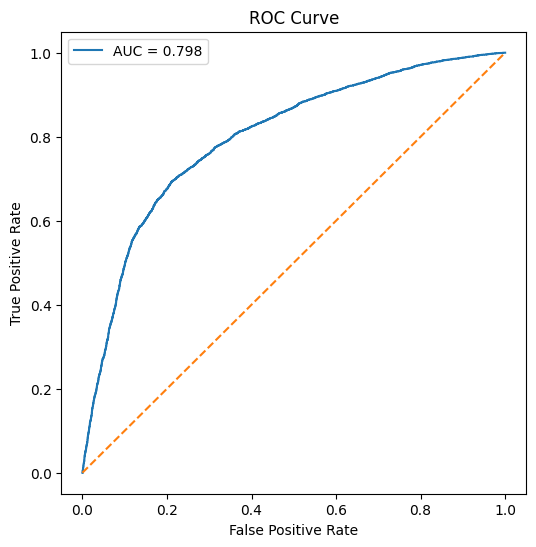

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = loaded_model.predict(X_test).ravel()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("output/images/roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import os
os.makedirs("output/models", exist_ok=True)
model.save("output/models/heart_disease_ann.keras")

In [ ]:
RANDOM_STATE = 42

TEST_SIZE = 0.2

TARGET_COLUMN = "cardio"

MODEL_PATH = "models/heart_disease_ann.keras"

SCALER_PATH = "models/scaler.pkl"

In [ ]:
import os
import sys
import importlib

# Ensure /content is in sys.path for module discovery in Colab
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Create src directory and files
os.makedirs("src", exist_ok=True)
os.makedirs("output/models", exist_ok=True)

# Create __init__.py
with open("src/__init__.py", "w") as f:
    pass # Empty init file

# Create constants.py
constants_content = """
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = "cardio"
MODEL_PATH = "output/models/heart_disease_ann.keras"
SCALER_PATH = "output/models/scaler.pkl"
"""
with open("src/constants.py", "w") as f:
    f.write(constants_content.strip())

# Create data_loader.py
data_loader_content = """
import pandas as pd

def load_data():
    df = pd.read_csv("/content/Dataset/Cardio Dataset.csv", sep=';')
    return df
"""
with open("src/data_loader.py", "w") as f:
    f.write(data_loader_content.strip())

# Create preprocessing.py
preprocessing_content = """
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os
from . import constants as const

def preprocess_data(df):
    # Drop duplicates
    df.drop_duplicates(inplace=True)

    # Separate features and target
    X = df.drop(const.TARGET_COLUMN, axis=1)
    y = df[const.TARGET_COLUMN]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=const.TEST_SIZE,
        random_state=const.RANDOM_STATE
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the scaler
    os.makedirs(os.path.dirname(const.SCALER_PATH), exist_ok=True)
    joblib.dump(scaler, const.SCALER_PATH)

    return X_train_scaled, X_test_scaled, y_train, y_test
"""
with open("src/preprocessing.py", "w") as f:
    f.write(preprocessing_content.strip())

# Create machine_learning.py
machine_learning_content = """
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
from . import constants as const

def train_models(X_train, X_test, y_train, y_test):
    # Traditional ML Models
    models = {
        "Logistic Regression": LogisticRegression(random_state=const.RANDOM_STATE),
        "KNN": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=const.RANDOM_STATE),
        "Random Forest": RandomForestClassifier(random_state=const.RANDOM_STATE),
        "SVM": SVC(random_state=const.RANDOM_STATE)
    }

    accuracies = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracies[name] = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {accuracies[name]:.4f}")

    # ANN Model
    model_ann = Sequential()
    model_ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model_ann.add(Dense(32, activation='relu'))
    model_ann.add(Dropout(0.3))
    model_ann.add(Dense(16, activation='relu'))
    model_ann.add(Dense(1, activation='sigmoid'))

    model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        verbose=0,
        patience=25,
        restore_best_weights=True
    )

    print("Training ANN Model...")
    history = model_ann.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    loss, accuracy_ann = model_ann.evaluate(X_test, y_test, verbose=0)
    print(f"ANN Test Accuracy: {accuracy_ann:.4f}")
    accuracies["ANN"] = accuracy_ann

    # Save the best performing ANN model
    os.makedirs(os.path.dirname(const.MODEL_PATH), exist_ok=True)
    model_ann.save(const.MODEL_PATH)

    # Identify and save the best traditional model
    best_traditional_model_name = None
    max_accuracy = -1
    for name, acc in accuracies.items():
        if name != "ANN" and acc > max_accuracy:
            max_accuracy = acc
            best_traditional_model_name = name

    if best_traditional_model_name:
        best_traditional_model = models[best_traditional_model_name]
        joblib.dump(best_traditional_model, "output/models/best_traditional_model.pkl")
        print(f"Saved best traditional model: {best_traditional_model_name} to output/models/best_traditional_model.pkl")


    return accuracies, history, model_ann
"""
with open("src/machine_learning.py", "w") as f:
    f.write(machine_learning_content.strip())

# Reload modules to ensure latest versions are used
import src.constants
import src.data_loader
import src.preprocessing
import src.machine_learning

importlib.reload(src.constants)
importlib.reload(src.data_loader)
importlib.reload(src.preprocessing)
importlib.reload(src.machine_learning)


# Original imports and main function call
from src.data_loader import load_data
from src.preprocessing import preprocess_data
from src.machine_learning import train_models

def main():

    df = load_data()

    X_train, X_test, y_train, y_test = preprocess_data(df)

    train_models(X_train, X_test, y_train, y_test)

if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Cardio Dataset.csv'